In [ ]:
# Datenbeschreibung – Datensatz zu Herzerkrankungen

#In diesem Notebook wird der Datensatz zu Herzerkrankungen analysiert. 
#Ziel ist es, den Datensatz zu untersuchen, statistische Werte zu berechnen und die Daten für maschinelles Lernen aufzubereiten.

#Der Datensatz enthält medizinische Informationen zu Patienten wie Alter, Cholesterinspiegel, Blutdruck und Herzfrequenz.

In [6]:
!pip install pandas numpy matplotlib scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
import os
os.getcwd()

'C:\\Users\\B.Ajdini.inf24\\OneDrive - Alte Kantonsschule Aarau\\Desktop\\Baden 2. Klasse\\Modul 259'

In [11]:
os.listdir()

['.ipynb_checkpoints',
 'Dataset',
 'data_description.ipynb',
 'heart.csv',
 'LB_M259_v2.pdf',
 'MLP_259.xlsx',
 'Tag 1',
 'Tag 2',
 'Tag 3',
 'Tag 4']

In [12]:
df = pd.read_csv("heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [13]:
df.shape

(1025, 14)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## Überblick über den Datensatz
Der Datensatz enthält medizinische Merkmale von Patienten wie Alter, Cholesterinspiegel, Blutdruck und Herzfrequenz.
Jede Zeile steht für einen Patienten.

## Zielvariable

Die Zielvariable lautet **target**.

0 = Keine Herzerkrankung  
1 = Herzerkrankung

Das Ziel besteht darin, diesen Wert anhand der anderen Attribute vorherzusagen.

In [15]:
df["target"].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [17]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [16]:
df["age"].median()

np.float64(56.0)

In [18]:
df["chol"].mean()

np.float64(246.0)

In [19]:
df["trestbps"].std()

np.float64(17.516718005376408)

## Statistische Analyse

Statistische Kennzahlen helfen uns, den Datensatz zu verstehen.

Der Mittelwert gibt den Durchschnittswert an, der Median den Mittelwert und die Standardabweichung zeigt an, wie stark die Werte variieren.

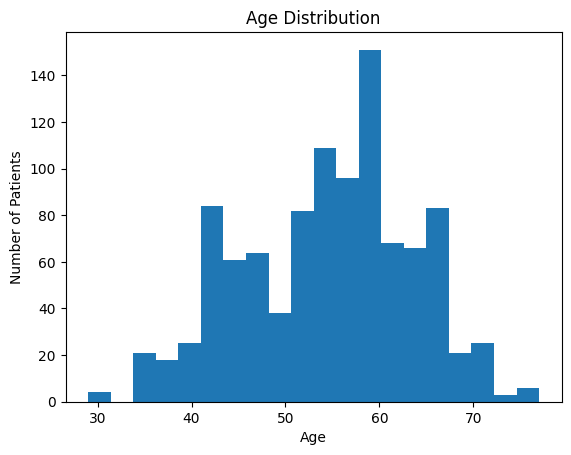

In [20]:
plt.hist(df["age"], bins=20)
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution")
plt.show()

Das Histogramm zeigt, wie sich das Alter der Patienten im Datensatz verteilt.
Die meisten Patienten sind zwischen 40 und 60 Jahre alt.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()
df["age_scaled"] = scaler.fit_transform(df[["age"]])
df[["age","age_scaled"]].head()

,age,age_scaled
0,52,-0.268437
1,53,-0.158157
2,70,1.716595
3,61,0.724079
4,62,0.834359


Die Skalierung ist für Algorithmen des maschinellen Lernens entscheidend, da Merkmale oft sehr unterschiedliche Wertebereiche haben. Im vorliegenden Datensatz variiert das Alter beispielsweise nur um wenige Jahrzehnte, während der Cholesterinwert in die Hunderte geht. Ohne Anpassung würden Modelle grössere Zahlenwerte fälschlicherweise als wichtiger einstufen.

Besonders distanzbasierte Verfahren wie k-Nearest Neighbors oder neuronale Netze reagieren empfindlich auf solche Unterschiede. Durch die Standardisierung bringen wir alle Features auf eine gemeinsame Basis: Der Mittelwert wird 0 und die Standardabweichung 1. Dies verhindert eine Verzerrung der Ergebnisse und hilft dem Modell, Muster in den Daten effizienter und korrekter zu lernen.